# LAB 1 

- Jerónimo Vásquez Ponce 202223824
- Jacobo Zarruk Estrada 202223913

In [300]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn import linear_model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score, cross_val_predict, train_test_split
from sklearn import preprocessing
from sklearn.preprocessing import MinMaxScaler



## Extracción de los datos

In [301]:
df = pd.read_csv("Datos Lab 1.csv")

## EDA

In [302]:
df.head()

,Patient ID,Date of Service,Sex,Age,Weight (kg),Height (m),BMI,Abdominal Circumference (cm),Blood Pressure (mmHg),Total Cholesterol (mg/dL),...,Physical Activity Level,Family History of CVD,Height (cm),Waist-to-Height Ratio,Systolic BP,Diastolic BP,Blood Pressure Category,Estimated LDL (mg/dL),CVD Risk Score,CVD Risk Level
0,isDx5313,"November 08, 2023",M,44.0,114.300,1.720,38.600,100.000,112/83,228.0,...,High,N,172.000,0.581,112.0,83.0,Hypertension Stage 1,121.0,19.880,HIGH
1,LHCK2961,20/03/2024,F,57.0,92.923,1.842,33.116,106.315,101/91,158.0,...,High,Y,184.172,0.577,101.0,91.0,Hypertension Stage 2,57.0,16.833,INTERMEDIARY
2,WjVn1699,2021-05-27,F,NaN,73.400,1.650,27.000,78.100,90/74,135.0,...,High,N,165.000,0.473,90.0,74.0,Normal,45.0,12.600,LOW
3,dCDO1109,"April 18, 2022",F,35.0,113.300,1.780,35.800,79.600,92/89,158.0,...,Moderate,Y,178.000,0.447,92.0,89.0,Hypertension Stage 1,94.0,14.920,HIGH
4,pnpE1080,01/11/2024,F,48.0,102.200,1.750,33.400,106.700,121/68,207.0,...,Low,Y,175.000,0.610,121.0,68.0,Elevated,128.0,18.870,HIGH


In [303]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1639 entries, 0 to 1638
Data columns (total 24 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Patient ID                    1639 non-null   object 
 1   Date of Service               1639 non-null   object 
 2   Sex                           1639 non-null   object 
 3   Age                           1571 non-null   float64
 4   Weight (kg)                   1566 non-null   float64
 5   Height (m)                    1578 non-null   float64
 6   BMI                           1586 non-null   float64
 7   Abdominal Circumference (cm)  1578 non-null   float64
 8   Blood Pressure (mmHg)         1639 non-null   object 
 9   Total Cholesterol (mg/dL)     1571 non-null   float64
 10  HDL (mg/dL)                   1557 non-null   float64
 11  Fasting Blood Sugar (mg/dL)   1585 non-null   float64
 12  Smoking Status                1639 non-null   object 
 13  Dia

In [304]:
df.describe()

,Age,Weight (kg),Height (m),BMI,Abdominal Circumference (cm),Total Cholesterol (mg/dL),HDL (mg/dL),Fasting Blood Sugar (mg/dL),Height (cm),Waist-to-Height Ratio,Systolic BP,Diastolic BP,Estimated LDL (mg/dL),CVD Risk Score
count,1571.000000,1566.000000,1578.000000,1586.000000,1578.000000,1571.000000,1557.000000,1585.000000,1571.000000,1563.000000,1578.000000,1554.000000,1582.000000,1610.000000
mean,46.803186,85.666006,1.757439,28.424744,91.538861,199.043673,56.183558,117.836860,175.770082,0.522440,125.632637,82.887536,113.235896,18.227281
std,13.039479,21.712504,0.118012,7.309275,13.427985,59.388670,16.721702,32.379634,11.695880,0.085692,22.577463,15.503625,61.435291,10.767666
min,6.134000,13.261000,1.371000,4.317000,49.542000,-1.256000,0.008000,15.306000,136.498000,0.250000,49.914000,31.720000,-92.055000,-20.057000
25%,37.000000,67.100000,1.666500,22.600000,79.700000,150.000000,42.000000,92.000000,167.000000,0.453000,108.000000,71.000000,62.000000,15.150000
50%,46.000000,86.314000,1.760000,28.000000,91.200000,199.000000,56.000000,115.000000,176.000000,0.519000,125.000000,82.000000,112.000000,16.967000
75%,55.000000,104.801500,1.850000,33.963000,102.267250,250.000000,70.000000,139.000000,185.000000,0.582000,141.000000,93.000000,159.000000,18.900000
max,89.420000,158.523000,2.146000,53.028000,136.336000,385.679000,110.315000,219.667000,214.394000,0.804000,202.711000,134.066000,317.314000,114.980000


In [305]:
df.shape

(1639, 24)

### Reporte de calidad de los datos

In [306]:
def reporte_calidad(df):

    reporte_de_cualidad = {
        'Total datos': len(df),
        'Datos duplicados': df.duplicated().sum(),
        'Valores nulos': df.isnull().sum().to_dict(),
        'Tipos de datos': df.dtypes.astype(str).to_dict(),
        

    }

    return reporte_de_cualidad

print(reporte_calidad(df))

{'Total datos': 1639, 'Datos duplicados': 151, 'Valores nulos': {'Patient ID': 0, 'Date of Service': 0, 'Sex': 0, 'Age': 68, 'Weight (kg)': 73, 'Height (m)': 61, 'BMI': 53, 'Abdominal Circumference (cm)': 61, 'Blood Pressure (mmHg)': 0, 'Total Cholesterol (mg/dL)': 68, 'HDL (mg/dL)': 82, 'Fasting Blood Sugar (mg/dL)': 54, 'Smoking Status': 0, 'Diabetes Status': 0, 'Physical Activity Level': 0, 'Family History of CVD': 0, 'Height (cm)': 68, 'Waist-to-Height Ratio': 76, 'Systolic BP': 61, 'Diastolic BP': 85, 'Blood Pressure Category': 0, 'Estimated LDL (mg/dL)': 57, 'CVD Risk Score': 29, 'CVD Risk Level': 0}, 'Tipos de datos': {'Patient ID': 'object', 'Date of Service': 'object', 'Sex': 'object', 'Age': 'float64', 'Weight (kg)': 'float64', 'Height (m)': 'float64', 'BMI': 'float64', 'Abdominal Circumference (cm)': 'float64', 'Blood Pressure (mmHg)': 'object', 'Total Cholesterol (mg/dL)': 'float64', 'HDL (mg/dL)': 'float64', 'Fasting Blood Sugar (mg/dL)': 'float64', 'Smoking Status': 'obje

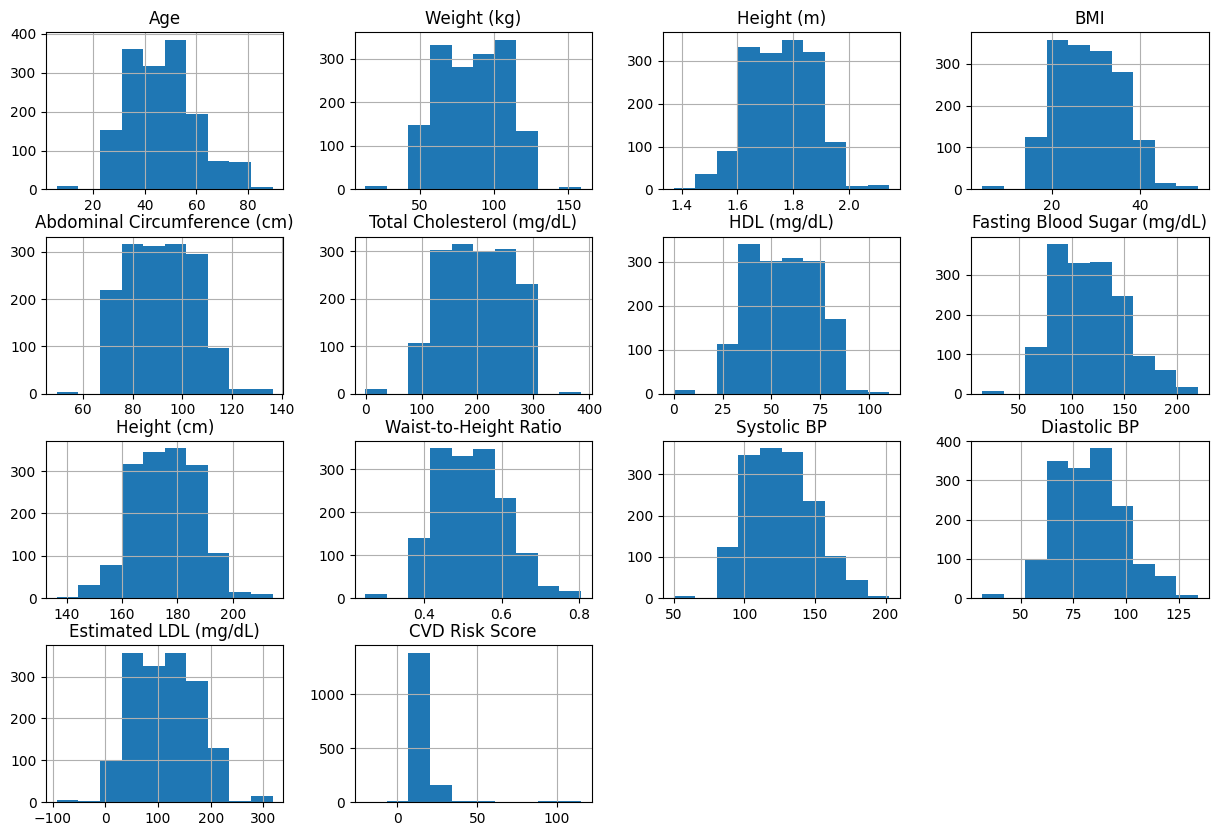

In [307]:
df.hist(figsize=(15,10))
plt.show()

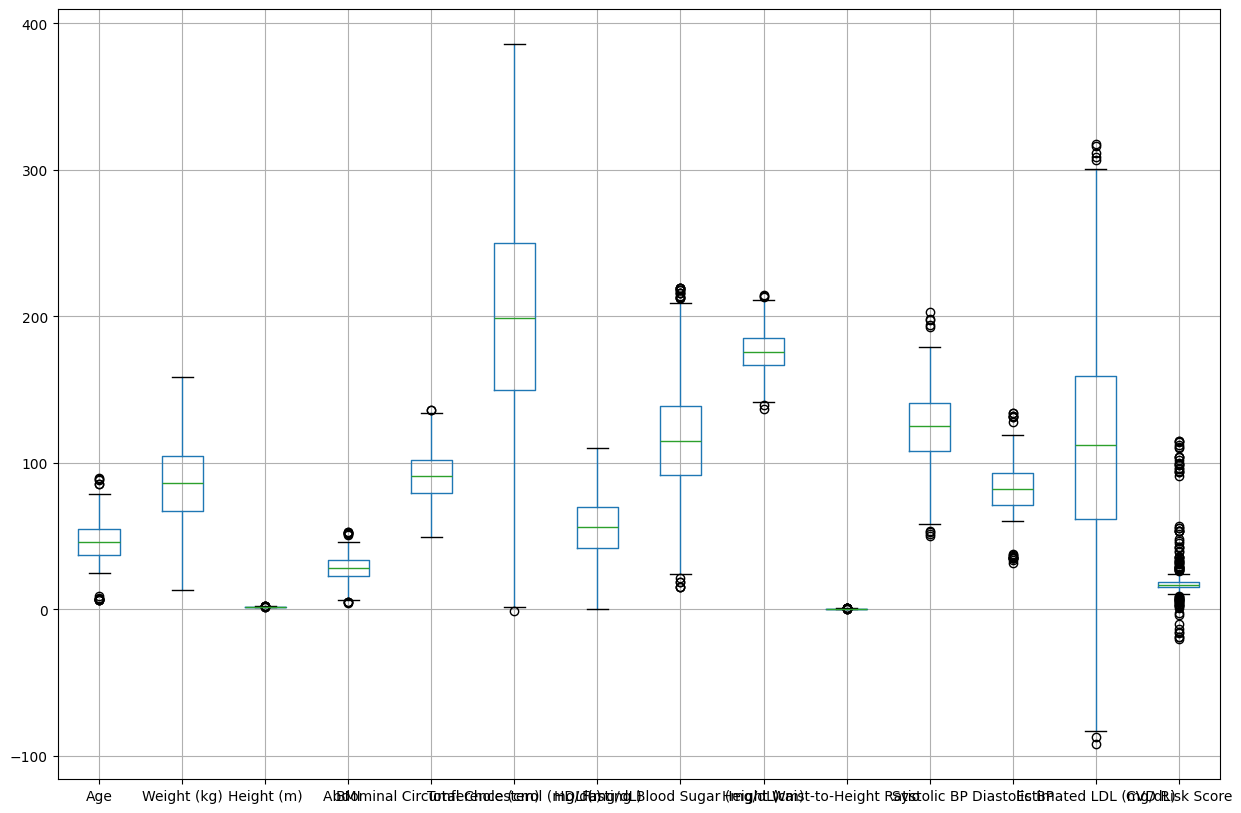

In [308]:
df.boxplot(figsize=(15,10))
plt.show()

In [309]:
def identificar_outliers(df, columna):

    
    
    Q1 = df[columna].quantile(0.25)  
    Q3 = df[columna].quantile(0.75) 
    IQR = Q3 - Q1  
    
    
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    
    
    mask_outliers = (df[columna] < limite_inferior) | (df[columna] > limite_superior)
    indices_outliers = df[mask_outliers].index.tolist()
    outliers_df = df.loc[indices_outliers]
    
    
    limites = {
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'limite_inferior': limite_inferior,
        'limite_superior': limite_superior
    }
    
    return indices_outliers, outliers_df, limites



Vamos a analizar los ouliers con base a el boxplot, hay columnas donde estos outliers no debe por que estar mal como en 'Age' que solo son personas como nas de 82 años o menores de 10 años, igual pasa con la altura

Por otro lado columnas como 'BMI' que si presneta posibles errores como personas con BMI de 5 o 4 lo cual lo podriamos categorizar como anomalias pues los valores del BMI varian entre 18 y 30 (posible mas en casos de obesidad extrema), sin embargo valores de 4 o 5 son casi imposibles en personas adultas. Por otro lado, en la columna 'Abdominal Circumference (cm)' se presentan dos ouliers extraños pues dos personas presentan una circunferencia abdonminal superiro a 136 pero en BMI no corresponden como obesos.

En cuanto a la columna 'Total Cholesterol (mg/dL)' hay un unico outlier con valor negativo -1.256 lo cual no es posible.

En cuanto a la columna 'Fasting Blood Sugar' hay valores 15.6, 18.9 ,19.0, 21.2 lo caul corersponden a valores extremos que solo corresponden a pacientes en coma

En la columna Estimated LDL (mg/dL) hay valores extremadamente raros como valores negativos lo cual no es posible o pueden presentar un error al ingresar los datos

En la columna CVD Risk Score hay valores extremadamente raros como valores negativos lo cual no es posible o pueden presentar un error al ingresar los datos





Indices importantes Valores imposibles posibles errores.

- BMI -> 140, 169, 427
- Total Cholesterol (mg/dL) -> 1363
- Abdominal Circumference (cm) -> 209, 271
- Fasting Blood Sugar (mg/dL) -> 186, 314, 753, 884, 1042
- En la columna Estimated LDL (mg/dL) -> 176, 1440




In [310]:
indices_outliers, outliers_df, limites = identificar_outliers(df, 'CVD Risk Score')

print(outliers_df['CVD Risk Score'])



40        6.327
82       94.629
108      35.904
112       7.704
129      42.853
         ...   
1509      2.622
1562    111.008
1583    114.968
1586     33.384
1617    114.143
Name: CVD Risk Score, Length: 87, dtype: float64


In [311]:
print(limites)
print(indices_outliers)

{'Q1': 15.15, 'Q3': 18.9, 'IQR': 3.7499999999999982, 'limite_inferior': 9.525000000000002, 'limite_superior': 24.524999999999995}
[40, 82, 108, 112, 129, 134, 147, 154, 157, 162, 164, 232, 246, 292, 305, 311, 312, 313, 322, 325, 386, 402, 410, 418, 424, 507, 513, 553, 561, 588, 670, 673, 698, 704, 719, 727, 738, 744, 765, 838, 850, 887, 891, 962, 968, 977, 990, 1016, 1023, 1047, 1053, 1071, 1076, 1095, 1103, 1104, 1132, 1165, 1198, 1201, 1208, 1214, 1227, 1250, 1253, 1264, 1273, 1279, 1314, 1320, 1330, 1349, 1360, 1384, 1400, 1422, 1451, 1469, 1474, 1486, 1498, 1507, 1509, 1562, 1583, 1586, 1617]


In [312]:
df.loc[indices_outliers]

,Patient ID,Date of Service,Sex,Age,Weight (kg),Height (m),BMI,Abdominal Circumference (cm),Blood Pressure (mmHg),Total Cholesterol (mg/dL),...,Physical Activity Level,Family History of CVD,Height (cm),Waist-to-Height Ratio,Systolic BP,Diastolic BP,Blood Pressure Category,Estimated LDL (mg/dL),CVD Risk Score,CVD Risk Level
40,pEpZ9034,11/01/2020,M,58.0,117.800,1.660,42.700,103.300,113/73,249.0,...,Low,N,166.000,0.622,113.0,73.0,Normal,148.0,6.327,HIGH
82,sofs7024,11/12/2024,F,30.0,86.364,1.705,35.159,72.731,95/87,198.0,...,High,N,170.473,0.427,95.0,87.0,Hypertension Stage 1,97.0,94.629,INTERMEDIARY
108,Kbzi4901,2023-04-07,F,78.0,85.877,1.825,24.426,112.340,102/115,241.0,...,Low,N,182.485,0.616,102.0,115.0,Hypertension Stage 2,127.0,35.904,INTERMEDIARY
112,dSiv4949,2022-03-10,F,46.0,76.100,1.880,21.500,98.200,98/90,149.0,...,Low,Y,188.000,0.522,98.0,90.0,Hypertension Stage 2,55.0,7.704,HIGH
129,RlsB8509,29/08/2020,F,55.0,79.700,1.780,25.200,86.900,140/62,248.0,...,Moderate,Y,178.000,0.488,140.0,62.0,Hypertension Stage 2,182.0,42.853,HIGH
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1509,dJuC5084,"December 02, 2020",M,55.0,106.000,1.820,32.000,109.300,97/63,287.0,...,Moderate,N,182.000,0.601,97.0,63.0,Normal,222.0,2.622,HIGH
1562,RWyR9287,2025-04-07,M,60.0,69.200,1.900,19.200,88.500,123/72,121.0,...,Moderate,N,190.000,0.466,123.0,72.0,Elevated,47.0,111.008,INTERMEDIARY
1583,vmHe7241,"December 05, 2025",F,34.0,55.500,1.620,21.100,74.300,139/64,168.0,...,High,Y,162.000,0.459,139.0,64.0,Hypertension Stage 1,101.0,114.968,HIGH
1586,oSqq7069,18 Jun 23,F,38.0,68.516,1.929,39.967,96.957,105/84,241.0,...,Moderate,Y,192.936,0.503,105.0,84.0,Hypertension Stage 1,159.0,33.384,HIGH


### Analisis resultados reporte de calidad y outliers

En nuestro primer analisi de la calidad de los datos destacamos los siguientes descubrimientos:

- El total de datos son 1639
- Hay 23 columnas
- Hay 151 datos duplicados
- Hay valores nulos:

    - La columna 'Age' tiene 68 datos nulos
    - La columna 'Weight' tiene 73 datos nulos
    - La columna 'Height (m)' tiene 61 datos nulos
    - La columna 'BMI' tiene 53 datos nulos
    - La coumna 'Abdominal Circumference (cm)' tiene 61 datos nulos
    - La columna 'Total Cholesterol (mg/dL)' tiene 68 datos nulos
    - La columna 'HDL (mg/dL)' tiene 82 datos nulos
    - La columna 'Fasting Blood Sugar (mg/dL)' tiene 54 datos nulos
    - La columna 'Height (cm)' tiene 68 datos nulos
    - La columna 'Waist-to-Height Ratio' tiene 76 datos nulos
    - La columna 'Systolic BP' tiene 61 datos nulos
    - La columna 'Diastolic BP' tiene 85 datos nulos
    - La columna 'Estimated LDL (mg/dL)' tiene 57 datos nulos
    - La columna 'CVD Risk Score' tiene 29 datos nulos

- En cuanto a los tipos de datos:
    - Hay 10 datos tipo object
    - Hay 13 datos tipo float64



En cuanto a los outliers hay columnas que presentan outliers imposibles como: BMI, Total Cholesterol (mg/dL), Abdominal Circumference (cm), Fasting Blood Sugar (mg/dL) -> 186, 314, 753, 884, 1042, Estimated LDL (mg/dL) y CVD Score Risk, que pueden afectar el modelo sin embargo en columnas como: Age, weight entre otras tambien se presentan una suma importante de outliers posibles que podrian afectar el modelo 





Estos hallazgos nos permite concluir que:
- Los datos tienen problemas de completitud pues hay varios valores nulos
- Los datos tienen problemas de unicidad pues hay 151 datos duplicados
- Los datos tienen porblemas de cosnsitencia como que se presentan dos columnas height una en 'cm' y una en 'm'las cuales corresponden al mismo valor de altura. Del mismo modo, columnas como 'Date of service' tiene variaciones en como se represnetan las fechas pues estas se representan en diferentes formatos como: 20/03/2004 o November 08, 2023 o 2021-05-27	 
- Los datos presentan porblemas de validez por ejemplo en la columna 'Total Cholesterol (mg/dL)' se presentan valores negativos lo cual no es posible, las columnas 'Estimated LDL (mg/dL)' y 'CVD Risk Score' tambien tiene valores negativos lo cual puede represnetar un problema

## Transformación - Preparación de los datos


Nuestra propuesta de transformacion de los datos es la siguiente:
1) Para lidiar con los datos faltantes o nulos se utilizara el indicador de la mediana de la columna y se insertara la mediana en vez del dato nulo, esto se hace para no eliminar estos datos nulos y asignarle un valor que corresponde a la mitad d elos datos. No se usa el promedio, pues en valores con desviaciones estandares altas el promedio no es tan efectivo y no se usa la moda pues consideramos el valor de la mediana es mas efectivo para lidiar con los valores nulos
2) Para lidiar con los datos duplicados se eliminaran los datos duplicados dejando solo uno, esto busca asegurar que no hayan datos duplicados 
3) En cuanto a porblemas de consistencia se eliminara la columna de 'height (cm)' pues corresponde a la misma infromación de la columan 'Height (m)' y no es necesaria y se normalizaran las fechas a un solo tipo de fechas
4) Para lidiar con los outliers a pesar de que algunos sean posibles, para asegurar un mejor modelo se remplazaran todos los outliers por los limites, si esta por debajo del limite inferior se cambiara por el limite inferior y si esta por arriba del limite superior se cambiara por el limite superior

Estas transformaciones se hacen para asegurar unos datos de entranamiento lo mas adecuados posibles para el modelo

In [313]:
# 1) Remplzar los datos nulos por la mediana
for columna in df.columns:
    if df[columna].isnull().sum() > 0:
        mediana = df[columna].median()
        df[columna].fillna(mediana, inplace=True)

print(df.isnull().sum())


# Se cambiaron todos los datos nulos por la medaiana asegurando que ya no hayan datos nulos en el dataset


Patient ID                      0
Date of Service                 0
Sex                             0
Age                             0
Weight (kg)                     0
Height (m)                      0
BMI                             0
Abdominal Circumference (cm)    0
Blood Pressure (mmHg)           0
Total Cholesterol (mg/dL)       0
HDL (mg/dL)                     0
Fasting Blood Sugar (mg/dL)     0
Smoking Status                  0
Diabetes Status                 0
Physical Activity Level         0
Family History of CVD           0
Height (cm)                     0
Waist-to-Height Ratio           0
Systolic BP                     0
Diastolic BP                    0
Blood Pressure Category         0
Estimated LDL (mg/dL)           0
CVD Risk Score                  0
CVD Risk Level                  0
dtype: int64


In [314]:
# 2) Eiminar los datos duplicados

df = df.drop_duplicates()


print(df.duplicated().sum())
print(len(df))


# Se eliminaron todos los datos duplicados haciendo que ahora la cantidad de datos o de filas es de 1488, se eliminaron 151 datos duplicados

0
1488


In [315]:
# 3) Porblemas de consistencia
df = df.drop('Height (cm)', axis=1)

df.info()

# Aca se elimino la columna altura con cm ya que no es relavente 

<class 'pandas.core.frame.DataFrame'>
Index: 1488 entries, 0 to 1638
Data columns (total 23 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Patient ID                    1488 non-null   object 
 1   Date of Service               1488 non-null   object 
 2   Sex                           1488 non-null   object 
 3   Age                           1488 non-null   float64
 4   Weight (kg)                   1488 non-null   float64
 5   Height (m)                    1488 non-null   float64
 6   BMI                           1488 non-null   float64
 7   Abdominal Circumference (cm)  1488 non-null   float64
 8   Blood Pressure (mmHg)         1488 non-null   object 
 9   Total Cholesterol (mg/dL)     1488 non-null   float64
 10  HDL (mg/dL)                   1488 non-null   float64
 11  Fasting Blood Sugar (mg/dL)   1488 non-null   float64
 12  Smoking Status                1488 non-null   object 
 13  Diabetes

In [316]:
df['Date of Service'] = pd.to_datetime(df['Date of Service'], format='mixed', dayfirst=False)

# De esta manera estandarizamos todas las fechas para que todas esten en el mismo formato "año-mes-dia"

In [317]:
df.head()

,Patient ID,Date of Service,Sex,Age,Weight (kg),Height (m),BMI,Abdominal Circumference (cm),Blood Pressure (mmHg),Total Cholesterol (mg/dL),...,Diabetes Status,Physical Activity Level,Family History of CVD,Waist-to-Height Ratio,Systolic BP,Diastolic BP,Blood Pressure Category,Estimated LDL (mg/dL),CVD Risk Score,CVD Risk Level
0,isDx5313,2023-11-08,M,44.0,114.300,1.720,38.600,100.000,112/83,228.0,...,Y,High,N,0.581,112.0,83.0,Hypertension Stage 1,121.0,19.880,HIGH
1,LHCK2961,2024-03-20,F,57.0,92.923,1.842,33.116,106.315,101/91,158.0,...,Y,High,Y,0.577,101.0,91.0,Hypertension Stage 2,57.0,16.833,INTERMEDIARY
2,WjVn1699,2021-05-27,F,46.0,73.400,1.650,27.000,78.100,90/74,135.0,...,N,High,N,0.473,90.0,74.0,Normal,45.0,12.600,LOW
3,dCDO1109,2022-04-18,F,35.0,113.300,1.780,35.800,79.600,92/89,158.0,...,N,Moderate,Y,0.447,92.0,89.0,Hypertension Stage 1,94.0,14.920,HIGH
4,pnpE1080,2024-01-11,F,48.0,102.200,1.750,33.400,106.700,121/68,207.0,...,Y,Low,Y,0.610,121.0,68.0,Elevated,128.0,18.870,HIGH


In [318]:
# 4) Probelmas de outliers

data = df.copy()

for columna in data.select_dtypes(include='number').columns:
    indices, outliers, limites = identificar_outliers(data, columna)
    
    
    data.loc[data[columna] < limites['limite_inferior'], columna] = limites['limite_inferior']
    data.loc[data[columna] > limites['limite_superior'], columna] = limites['limite_superior']

# Aca le asignamos el valor de los limites a todos los outliers 


array([[<Axes: title={'center': 'Date of Service'}>,
        <Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Weight (kg)'}>,
        <Axes: title={'center': 'Height (m)'}>],
       [<Axes: title={'center': 'BMI'}>,
        <Axes: title={'center': 'Abdominal Circumference (cm)'}>,
        <Axes: title={'center': 'Total Cholesterol (mg/dL)'}>,
        <Axes: title={'center': 'HDL (mg/dL)'}>],
       [<Axes: title={'center': 'Fasting Blood Sugar (mg/dL)'}>,
        <Axes: title={'center': 'Waist-to-Height Ratio'}>,
        <Axes: title={'center': 'Systolic BP'}>,
        <Axes: title={'center': 'Diastolic BP'}>],
       [<Axes: title={'center': 'Estimated LDL (mg/dL)'}>,
        <Axes: title={'center': 'CVD Risk Score'}>, <Axes: >, <Axes: >]],
      dtype=object)

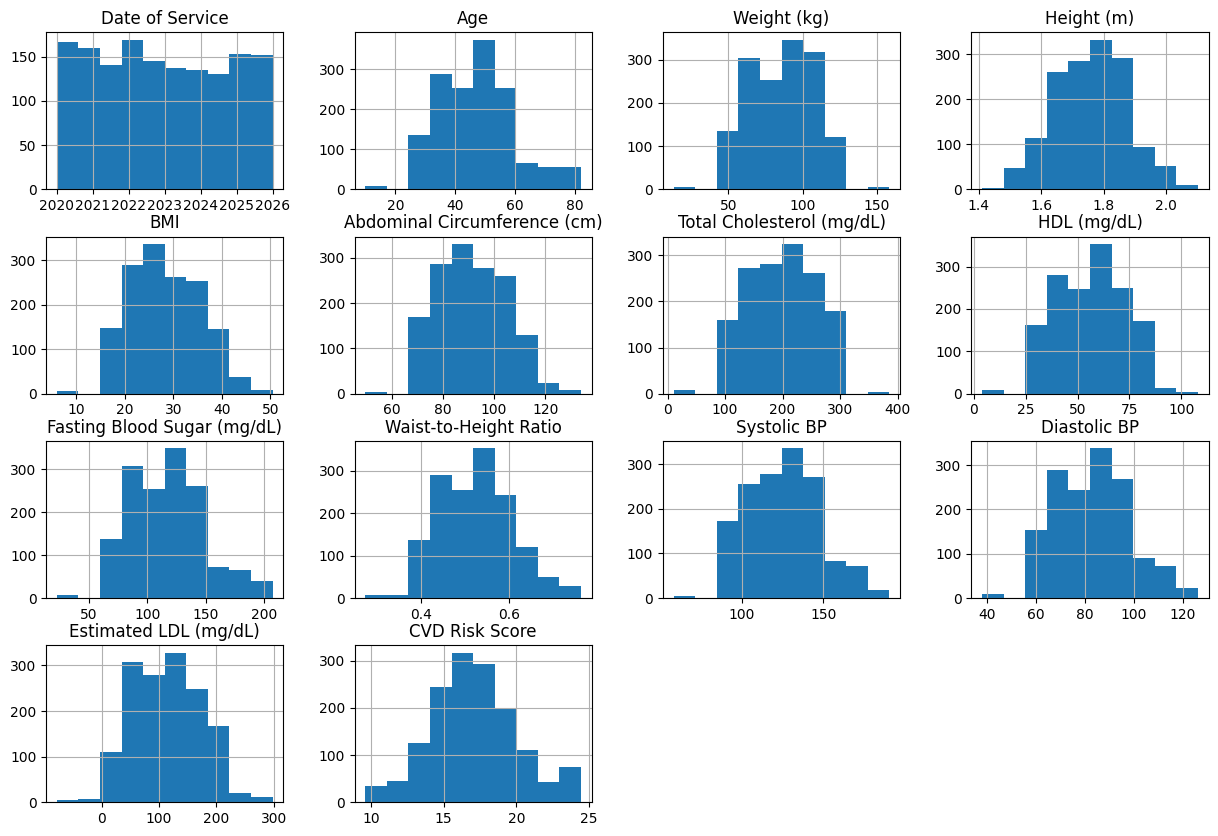

In [319]:
data.hist(figsize=(15,10))

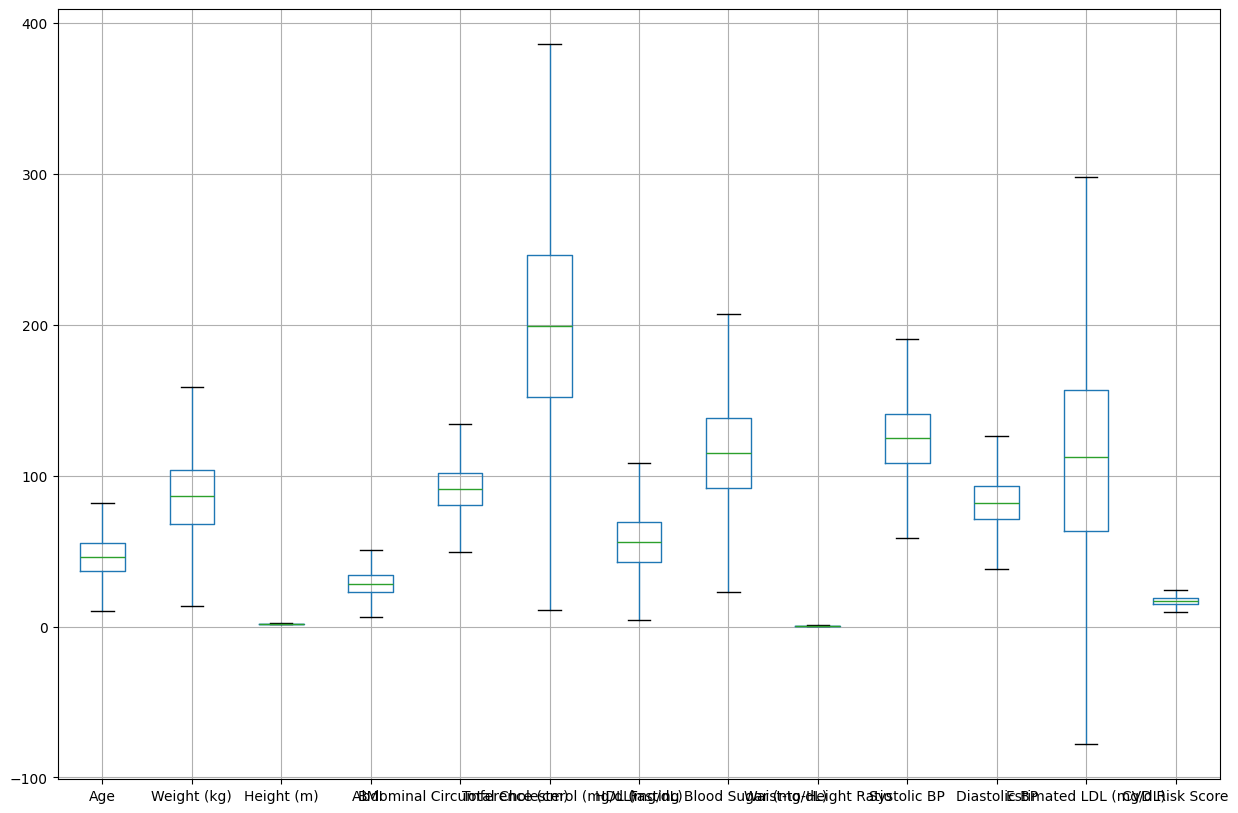

In [320]:
data.boxplot(figsize=(15,10))
plt.show()

Estas transformaciones se hicieron como preparacion de los datos para tener un mejor modelo 

## Modelo

### Selección variables importantes

y = CVD Risk Score


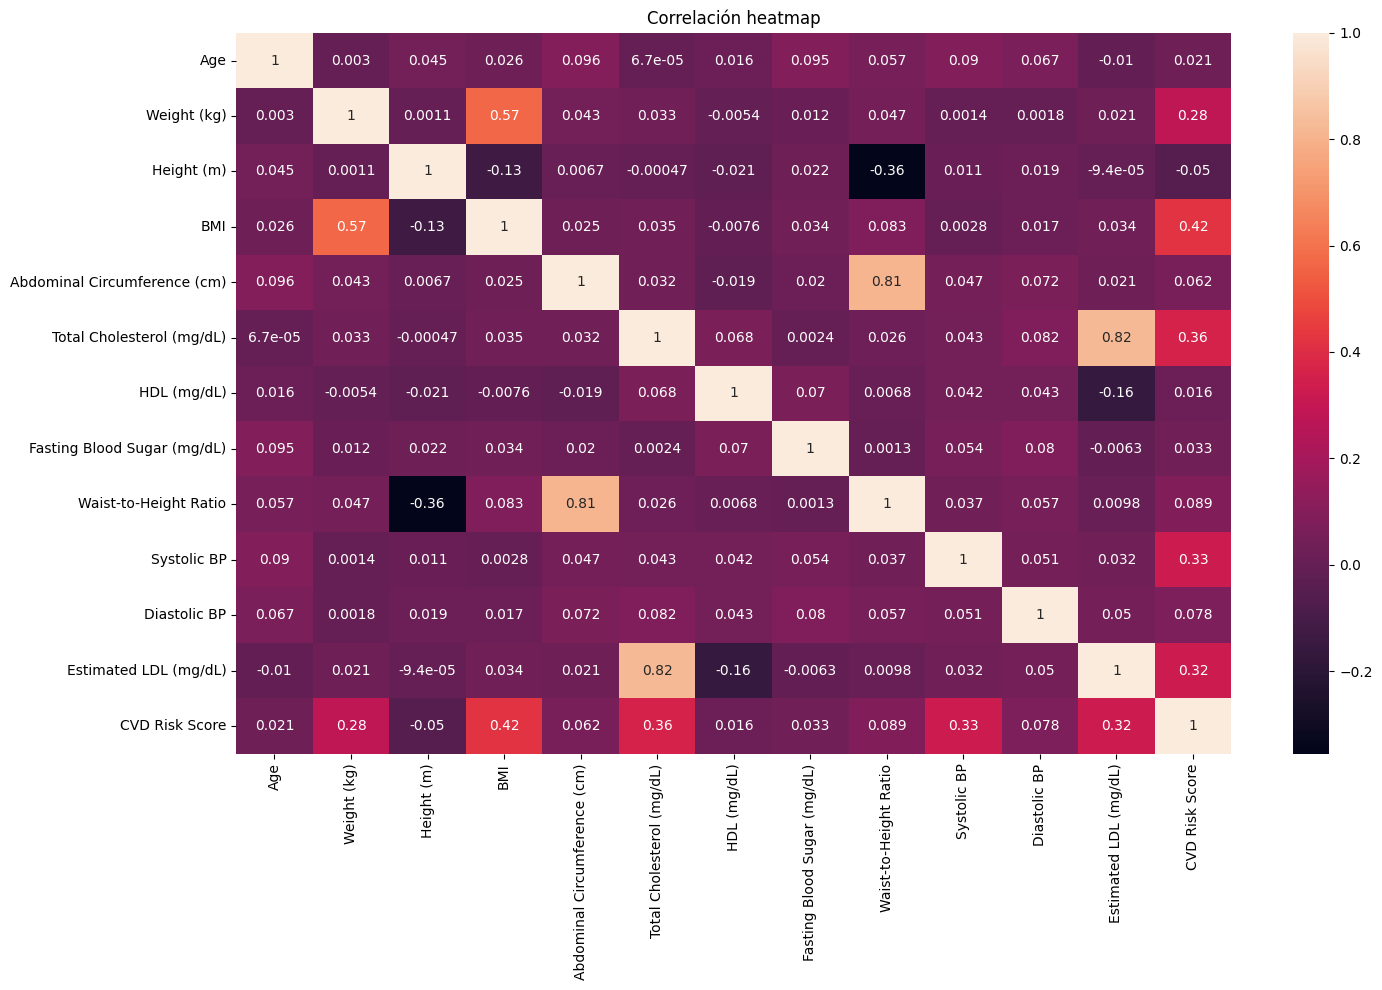

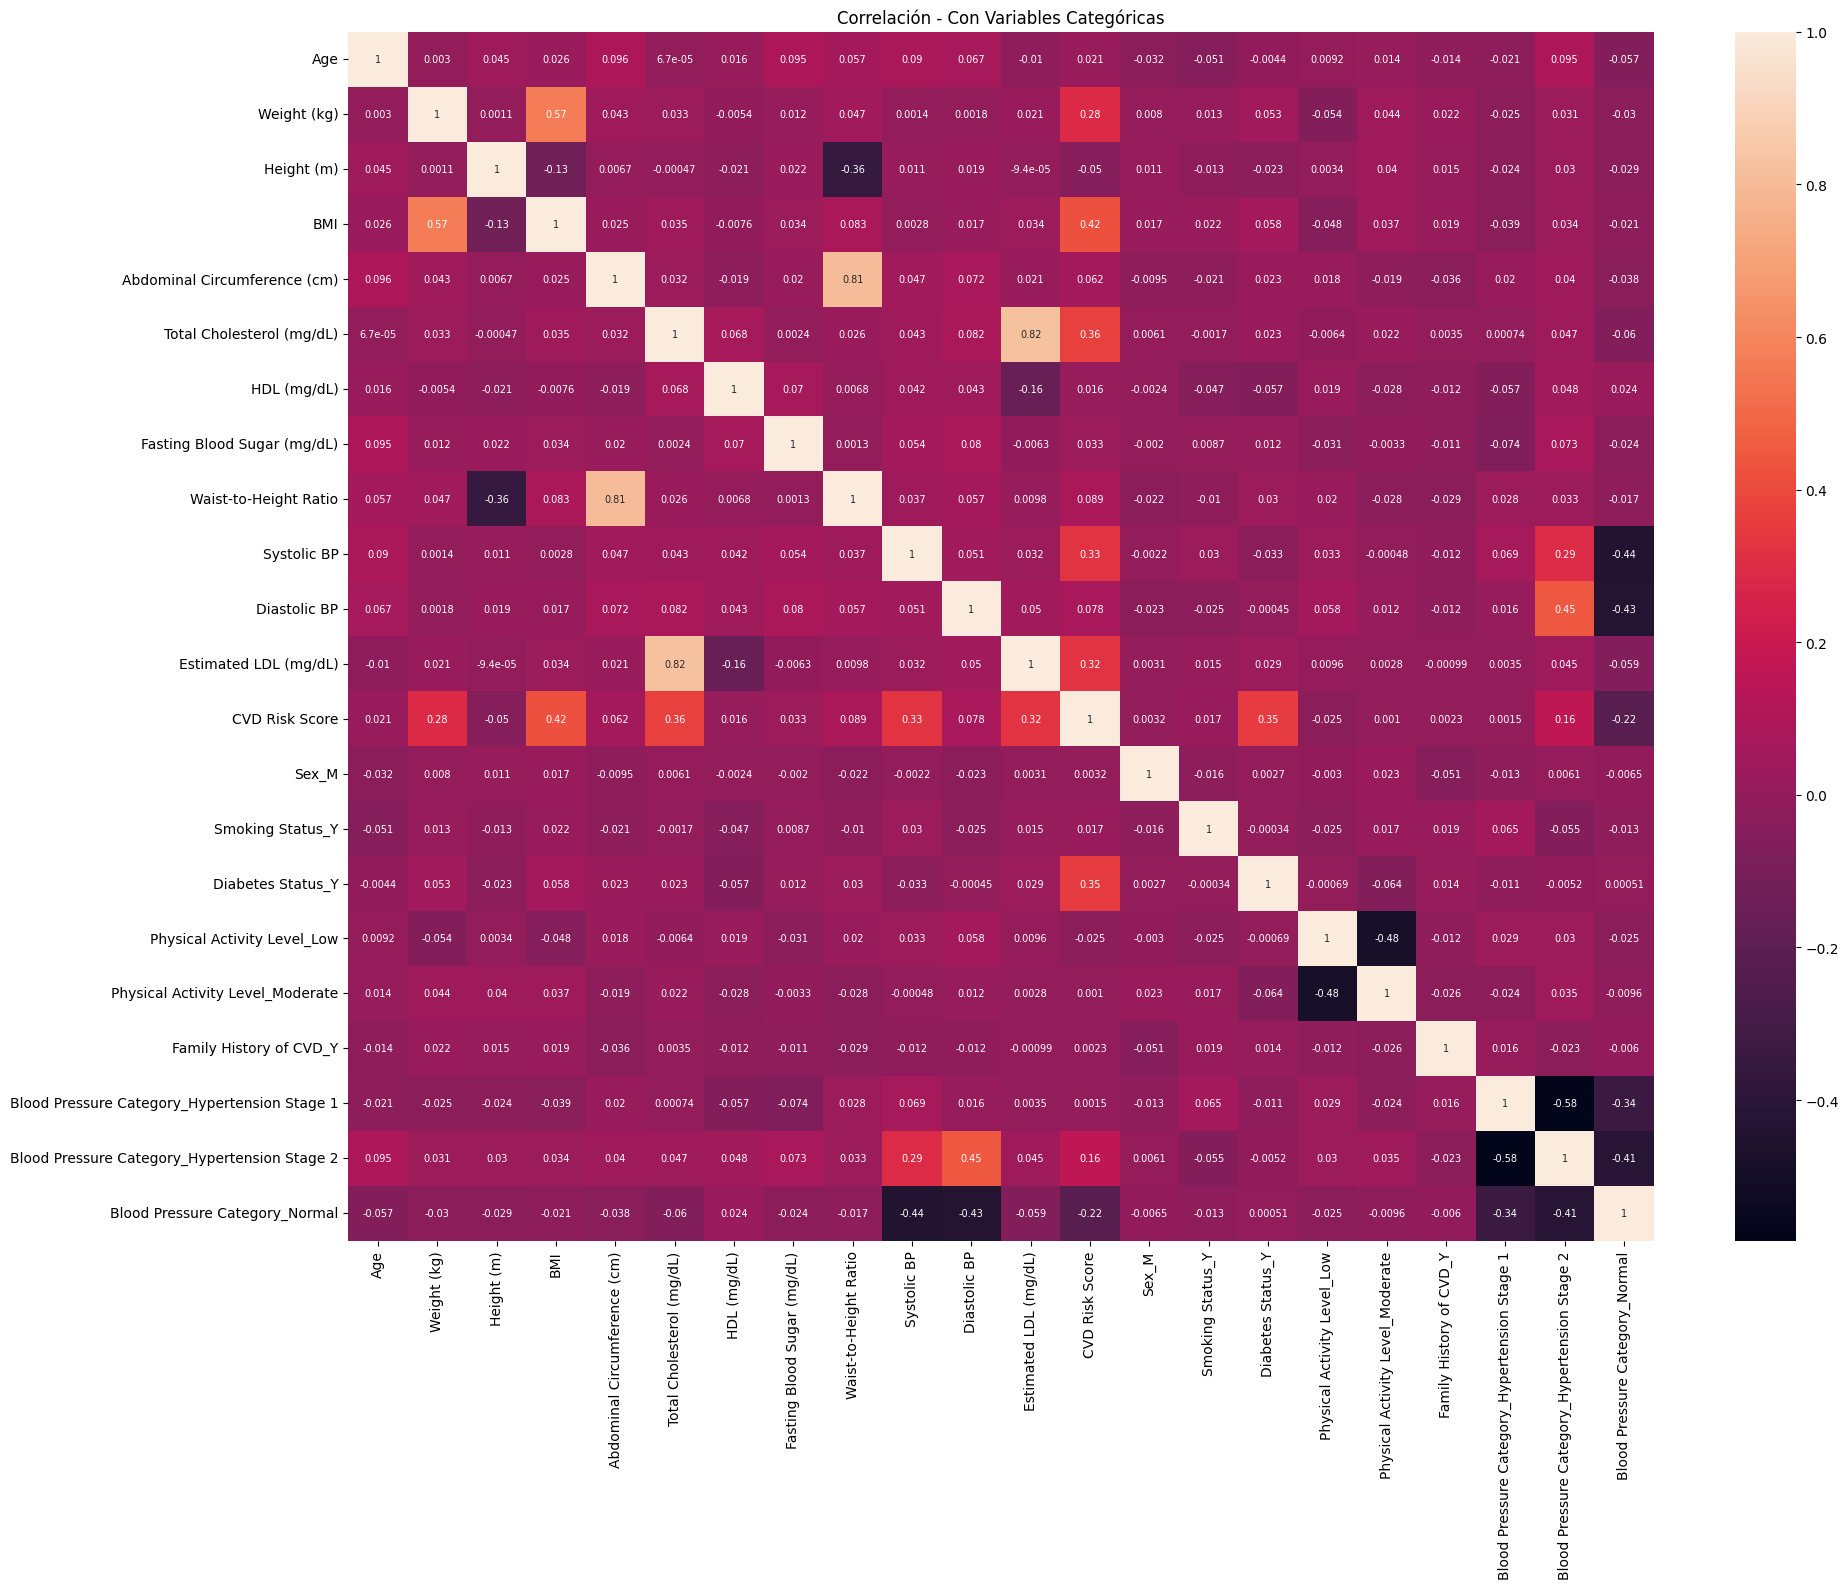

In [321]:

plt.figure(figsize=(15, 10))
corr_numeric = data.corr(numeric_only=True)
sns.heatmap(corr_numeric, annot=True)
plt.title('Correlación heatmap')
plt.tight_layout()
plt.show()


data_encoded = pd.get_dummies(data, columns=['Sex', 'Smoking Status', 'Diabetes Status', 'Physical Activity Level', 'Family History of CVD', 'Blood Pressure Category'], drop_first=True)

plt.figure(figsize=(20, 16))
corr_encoded = data_encoded.corr(numeric_only=True)
sns.heatmap(corr_encoded, annot=True, annot_kws={'size': 7})
plt.title('Correlación - Con Variables Categóricas')
plt.tight_layout()
plt.show()


<Axes: xlabel='BMI', ylabel='CVD Risk Score'>

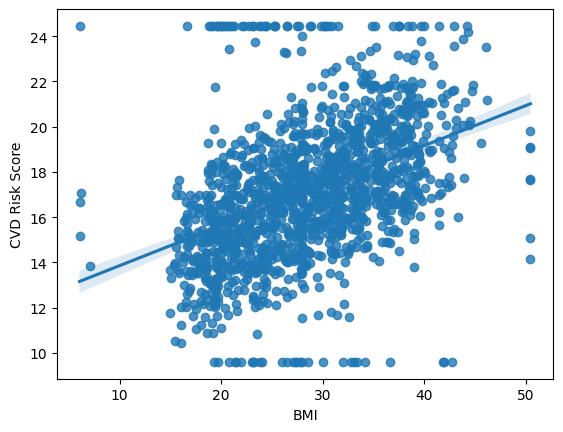

In [322]:
sns.regplot(data=data, x='BMI', y='CVD Risk Score')

<Axes: xlabel='BMI', ylabel='CVD Risk Score'>

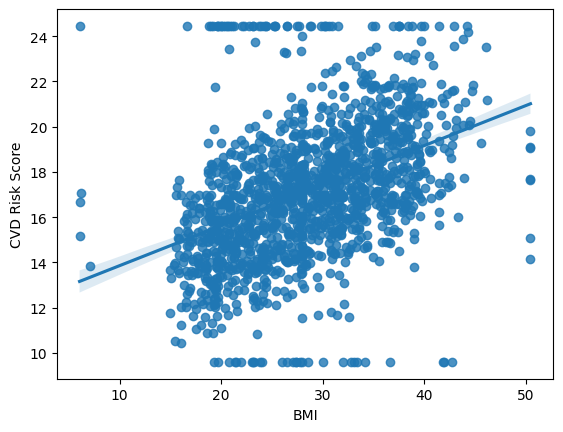

In [323]:
sns.regplot(data=data, x='BMI', y='CVD Risk Score')

<Axes: xlabel='Systolic BP', ylabel='CVD Risk Score'>

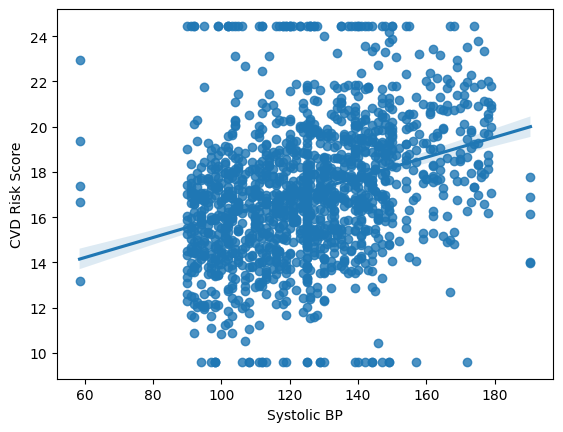

In [324]:
sns.regplot(data=data, x='Systolic BP', y='CVD Risk Score')

<Axes: xlabel='Estimated LDL (mg/dL)', ylabel='CVD Risk Score'>

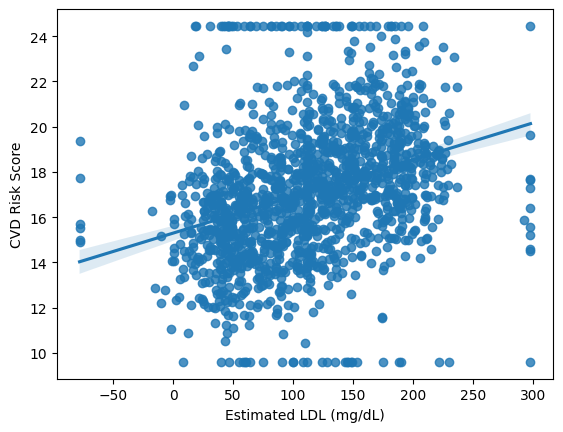

In [325]:
sns.regplot(data=data, x='Estimated LDL (mg/dL)', y='CVD Risk Score')

<Axes: xlabel='Weight (kg)', ylabel='CVD Risk Score'>

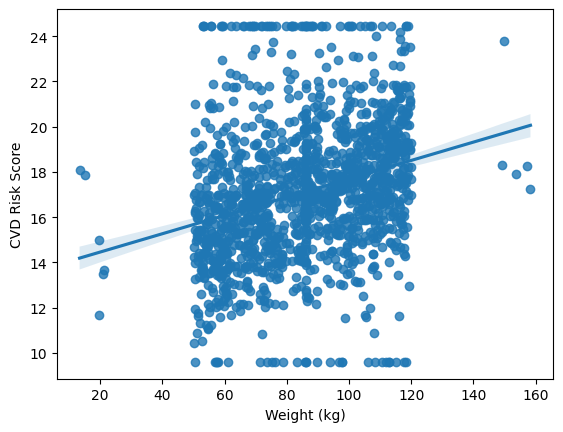

In [326]:
sns.regplot(data=data, x='Weight (kg)', y='CVD Risk Score')

In [327]:
data_encoded.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1488 entries, 0 to 1638
Data columns (total 26 columns):
 #   Column                                        Non-Null Count  Dtype         
---  ------                                        --------------  -----         
 0   Patient ID                                    1488 non-null   object        
 1   Date of Service                               1488 non-null   datetime64[ns]
 2   Age                                           1488 non-null   float64       
 3   Weight (kg)                                   1488 non-null   float64       
 4   Height (m)                                    1488 non-null   float64       
 5   BMI                                           1488 non-null   float64       
 6   Abdominal Circumference (cm)                  1488 non-null   float64       
 7   Blood Pressure (mmHg)                         1488 non-null   object        
 8   Total Cholesterol (mg/dL)                     1488 non-null   float64    

La grafica del mapa de calor tanto la normal como la que tiene valores encoded nos permite ver la correlacion existente entre diferentes columnas ya que nuestra variable objetivo (y) es CVD Risk Score, podemos ver que las columnas que tienen mas correlación son:
- BMI -> 0.421
- Total Cholesterol (mg/dL) -> 0.364
- Diabetes Status_Y -> 0.355
- Systolic BP -> 0.325
- Estimated LDL (mg/dL) -> 0.324
- Weight(kg) -> 0.28
- BP Category_Hypertension Stage 2 -> 0.161

Las graficas de regresion nos permite confirmar este hallazgo y solo cogemos las que son significativas osea que su coeficiente de correlacion es mayor a 0.15


Esto quiere decir que a la hora de hacer la regresion lineal multiple las columnas que mas pesan en el valor objetivo son estas, o que estas columnas deberian ser las x o valores independientes.

Primero es la division de los datos en train y test. Usaremos 80 % train y 20 % test que es una distribucion comun

In [328]:
X_multi = data_encoded[['BMI', 'Total Cholesterol (mg/dL)', 'Diabetes Status_Y', 'Systolic BP', 'Estimated LDL (mg/dL)', 'Weight (kg)', 'Blood Pressure Category_Hypertension Stage 2']].to_numpy()
y_multi = data_encoded[['CVD Risk Score']].to_numpy()

In [329]:
# Train test split
X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(X_multi, y_multi, test_size=0.2, random_state=42)

In [330]:

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train_multi)
X_test_scaled = scaler.transform(X_test_multi)

In [331]:
# Modelo

multi_lr = linear_model.LinearRegression()

multi_lr.fit(X_train_scaled, y_train_multi)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


Aca ya se realizo el entrenamiento del modelo y dio los siguientes coeficientes e interceptos

In [332]:
multi_coef = multi_lr.coef_
multi_intercept = multi_lr.intercept_

print('Coefficients: ', multi_coef)
print('Intercept: ', multi_intercept)

Coefficients:  [[6.58176373 5.52386675 2.0608982  5.59501427 1.09229511 0.93972326
  0.13075332]]
Intercept:  [6.04591695]


Dando como resultado la siguiente ecuacion de la regresion:

y = 6.04591695 + (6.58176373 * (Valor -> 'BMI')) + (5.52386675 * (Valor -> 'Total Cholesterol (mg/dL)')) + (2.0608982 * (Valor -> 'Diabetes Status_Y')) + (5.59501427 * (Valor -> 'Systolic BP')) + (1.09229511 * (Valor -> 'Estimated LDL (mg/dL)')) + (0.93972326 * (Valor -> 'Weight (kg)')) + (0.13075332 * (Valor -> 'Blood Pressure Category_Hypertension Stage 2'))

## Evaluación del modelo

In [333]:
y_pred_multi = multi_lr.predict(X_test_scaled)

In [334]:
multi_lr.score(X_test_scaled, y_test_multi)

0.5432773118310656

Mean absolute error: 0.92
Mean squared error: 3.78
Root mean squared error: 1.94
R2-score: 0.54


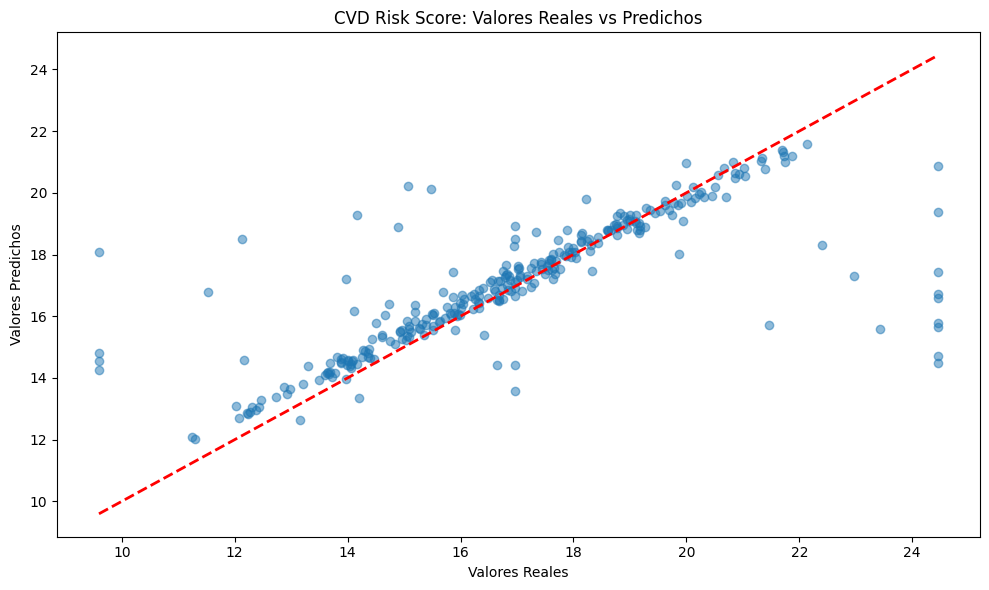

In [341]:
print("Mean absolute error: %.2f" % mean_absolute_error(y_test_multi, y_pred_multi))
print("Mean squared error: %.2f" % mean_squared_error(y_test_multi, y_pred_multi))
print("Root mean squared error: %.2f" % np.sqrt(mean_squared_error(y_test_multi, y_pred_multi)))
print("R2-score: %.2f" % r2_score(y_test_multi, y_pred_multi))

# Grafica de valores reales vs predichos
plt.figure(figsize=(10, 6))
plt.scatter(y_test_multi, y_pred_multi, alpha=0.5)
plt.plot([y_test_multi.min(), y_test_multi.max()], [y_test_multi.min(), y_test_multi.max()], 'r--', lw=2)
plt.xlabel('Valores Reales')
plt.ylabel('Valores Predichos')
plt.title('CVD Risk Score: Valores Reales vs Predichos')
plt.tight_layout()
plt.show()


## Conclusiones